## Lab report
https://vvitguntur-my.sharepoint.com/:b:/g/personal/pardhasaradhi_vvit_net/IQAVE6FelcDeR6TYpP-ez13pAaj-6KMq1x28d9fEYEvSWbo?e=PRK3on

### Part A: Setup and Data Loading

In [ ]:
# ── Imports ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

In [ ]:
# ── Reproducibility ──────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Load Reuters Dataset ─────────────────────────────────────────
NUM_WORDS = 10000
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=NUM_WORDS)

print('Training samples :', len(x_train))   # 8982
print('Test samples     :', len(x_test))     # 2246
print('Number of classes:', len(set(y_train)))  # 46
print('Sample article   :', x_train[0][:20], '...')
print('Label            :', y_train[0])  # e.g., 3 (class index)


2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples : 8982
Test samples     : 2246
Number of classes: 46
Sample article   : [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7] ...
Label            : 3


### Part B: Explore and Decode the Dataset

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Decoded newswire (first article):
<START> <UNK> <UNK> said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ...

Label: 3

Top 10 most frequent classes:
  Class  3:  3159 samples
  Class  4:  1949 samples
  Class 19:   549 samples
  Class 16:   444 samples
  Class  1:   432 samples
  Class 11:   390 samples
  Class 20:   269 samples
  Class 13:   172 samples
  Class  8:   139 samples
  Class 10:   124 samples


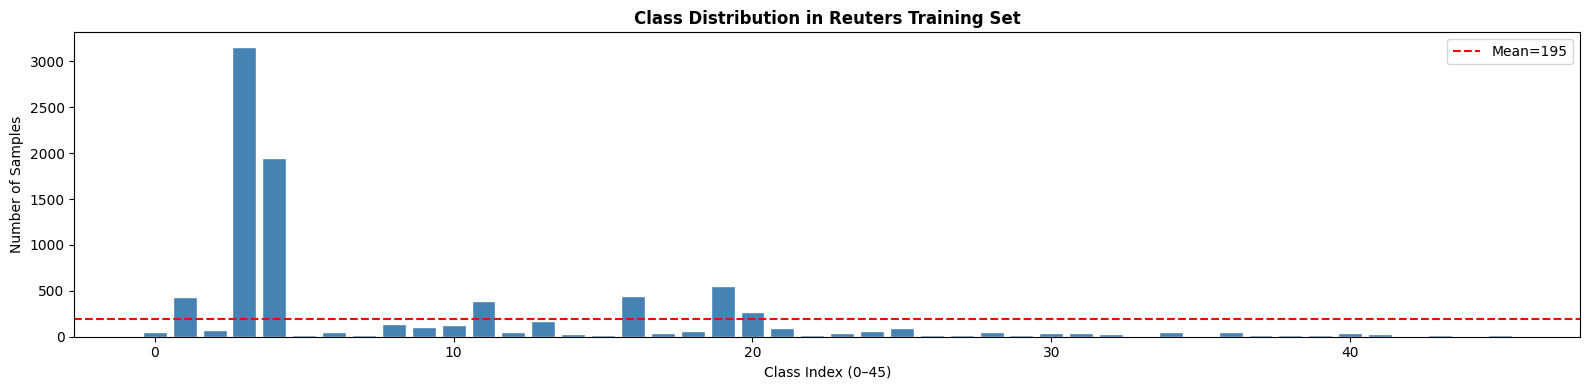

Note: Dataset is HIGHLY imbalanced!


In [ ]:
# ── Decode a newswire back to readable English ───────────────────
word_index = reuters.get_word_index()

# Build reverse mapping (shift by +3: 0=pad, 1=start, 2=unk, 3=unused)
reverse_index = {v + 3: k for k, v in word_index.items()}
reverse_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>'})

def decode_newswire(encoded):
    return ' '.join([reverse_index.get(i, '?') for i in encoded])

print('\nDecoded newswire (first article):')
print(decode_newswire(x_train[0])[:500], '...')
print('\nLabel:', y_train[0])

# ── Class Distribution ───────────────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)
print('\nTop 10 most frequent classes:')
sorted_idx = np.argsort(counts)[::-1]
for i in sorted_idx[:10]:
    print(f'  Class {unique[i]:2d}: {counts[i]:5d} samples')

# ── Visualize class distribution ─────────────────────────────────
plt.figure(figsize=(16, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Reuters Training Set', fontweight='bold')
plt.xlabel('Class Index (0–45)')
plt.ylabel('Number of Samples')
plt.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Mean={np.mean(counts):.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('exp8_class_distribution.png', dpi=150)
plt.show()
print('Note: Dataset is HIGHLY imbalanced!')


### Part C: Data Preprocessing

In [ ]:
x_train.shape

(8982,)

In [ ]:
# ── Multi-Hot Vectorization (same as Experiment 7) ───────────────
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train_vec = vectorize_sequences(x_train, NUM_WORDS)  # (8982, 10000)
x_test_vec  = vectorize_sequences(x_test,  NUM_WORDS)  # (2246, 10000)

# ── ONE-HOT ENCODE LABELS ─────────────────────────────────────────
# y_train currently: [3, 4, 3, 3, 5, ...]  (integer class indices)
# After to_categorical: each label becomes a 46-dim binary vector
NUM_CLASSES = 46
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)  # (8982, 46)
y_test_cat  = to_categorical(y_test,  num_classes=NUM_CLASSES)  # (2246, 46)

print('y_train before:', y_train[:5])
print('y_train after :', y_train_cat[:2])
print('x_train_vec shape:', x_train_vec.shape)
print('y_train_cat shape:', y_train_cat.shape)

# ── Train / Validation Split ──────────────────────────────────────
VAL_SIZE = 1000
x_val         = x_train_vec[:VAL_SIZE]
x_train_final = x_train_vec[VAL_SIZE:]
y_val         = y_train_cat[:VAL_SIZE]
y_train_final = y_train_cat[VAL_SIZE:]

print('\nSplit sizes → Train:', x_train_final.shape[0],
      '| Val:', x_val.shape[0], '| Test:', x_test_vec.shape[0])


y_train before: [3 4 3 4 4]
y_train after : [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
x_train_vec shape: (8982, 10000)
y_train_cat shape: (8982, 46)

Split sizes → Train: 7982 | Val: 1000 | Test: 2246


### Part D: Build the Neural Network

In [ ]:
# ── Model Architecture ───────────────────────────────────────────
def build_model(units=64, dropout_rate=0.4, lr=0.001):
    """
    KEY DIFFERENCES from Experiment 7:
    1. units=64 (not 16) — avoid information bottleneck with 46 classes
    2. Output: Dense(46) not Dense(1)
    3. Output activation: softmax not sigmoid
    4. Loss: categorical_crossentropy not binary_crossentropy
    """
    model = keras.Sequential([
        layers.Dense(units, activation='relu',
                     input_shape=(NUM_WORDS,),
                     name='hidden_1'),
        layers.Dropout(dropout_rate, name='dropout_1'),

        layers.Dense(units, activation='relu',
                     name='hidden_2'),
        layers.Dropout(dropout_rate, name='dropout_2'),

        # ★ Output: 46 neurons + softmax (one per class)
        layers.Dense(NUM_CLASSES, activation='softmax', name='output')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',   # ★ Not binary_crossentropy
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

# Parameter count for hidden_1:
# Weights: 10000 × 64 = 640,000
# Biases:  64
# Total:   640,064


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

### Part E: Train with Early Stopping

In [ ]:
# ── Callbacks ────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ── Train ─────────────────────────────────────────────────────────
history = model.fit(
    x_train_final, y_train_final,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print('\nStopped at epoch:', len(history.history['loss']))


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.3077 - loss: 3.4510 - val_accuracy: 0.5340 - val_loss: 2.6847
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.5164 - loss: 2.3521 - val_accuracy: 0.6010 - val_loss: 1.7404
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5955 - loss: 1.7400 - val_accuracy: 0.6550 - val_loss: 1.4439
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.6567 - loss: 1.4576 - val_accuracy: 0.6990 - val_loss: 1.3025
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.6922 - loss: 1.2972 - val_accuracy: 0.7260 - val_loss: 1.2112
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7214 - loss: 1.1771 - val_accuracy: 0.7520 - val_loss: 1.1505
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7390 - loss: 1.0790 - val_accuracy: 0.7530 - val_loss: 1.1010
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7603 - loss: 0.9861 - val_accuracy: 0.7680 - v

### Part F: Plot Training Curves

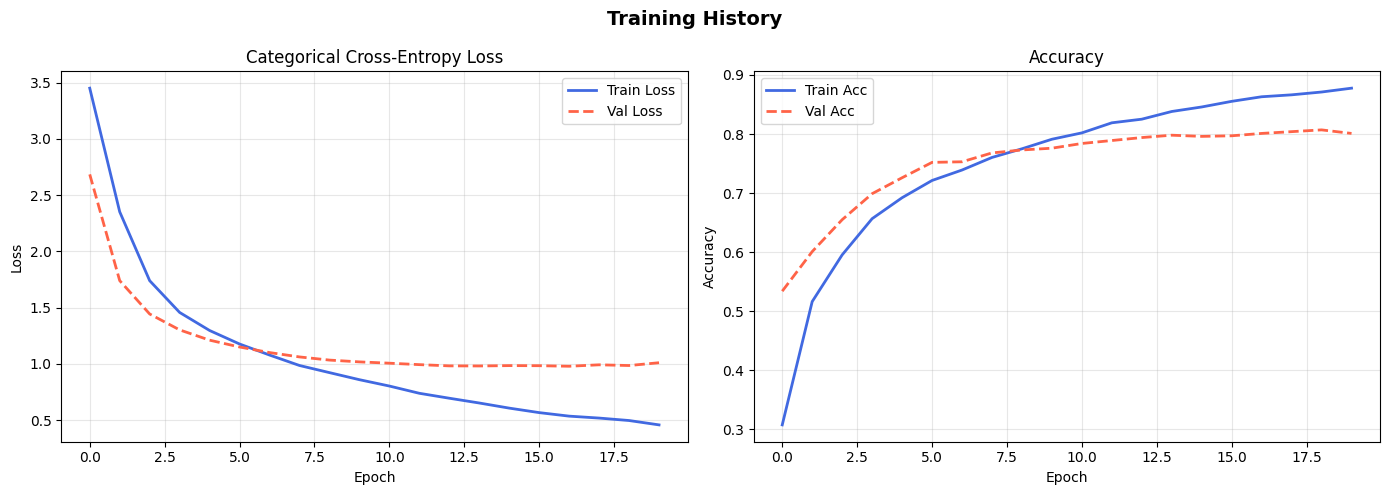

In [ ]:
def plot_history(history, title_prefix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title_prefix}Training History', fontsize=14, fontweight='bold')

    # Loss curve
    axes[0].plot(history.history['loss'],     label='Train Loss',
                 color='royalblue', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',
                 color='tomato', lw=2, linestyle='--')
    axes[0].set_title('Categorical Cross-Entropy Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy curve
    axes[1].plot(history.history['accuracy'],     label='Train Acc',
                 color='royalblue', lw=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Acc',
                 color='tomato', lw=2, linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'exp8_{title_prefix}curves.png', dpi=150)
    plt.show()

plot_history(history)


### Part G: Evaluate on Test Set

Test Loss     : 1.0642
Test Accuracy : 0.7716  (77.16%)
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report (top 10 classes shown):
              precision    recall  f1-score   support

           0       0.88      0.58      0.70        12
           1       0.63      0.80      0.70       105
           2       0.62      0.65      0.63        20
           3       0.92      0.94      0.93       813
           4       0.78      0.89      0.84       474
           5       0.00      0.00      0.00         5
           6       0.92      0.86      0.89        14
           7       0.00      0.00      0.00         3
           8       0.67      0.63      0.65        38
           9       0.80      0.80      0.80        25
          10       0.81      0.73      0.77        30
          11       0.54      0.81      0.65        83
          12       0.00      0.00      0.00        13
          13       0.51      0.54      0.53        37
          14       0.00      0.00      0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

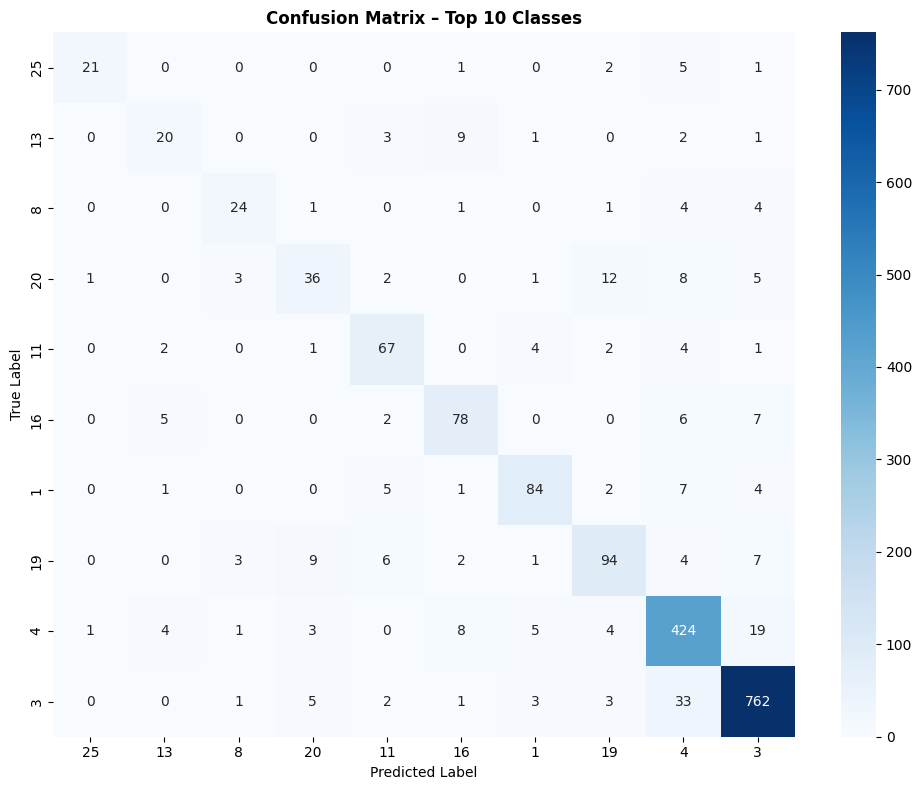

In [ ]:
# ── Test Set Evaluation ───────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test_vec, y_test_cat, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')

# ── Predictions ───────────────────────────────────────────────────
y_pred_prob = model.predict(x_test_vec)          # Shape: (2246, 46)
y_pred      = np.argmax(y_pred_prob, axis=1)     # Predicted class indices
y_true      = np.argmax(y_test_cat, axis=1)      # True class indices

# ── Classification Report ─────────────────────────────────────────
print('\nClassification Report (top 10 classes shown):')
report = classification_report(y_true, y_pred, output_dict=True)
# Show full report
print(classification_report(y_true, y_pred))

# ── Confusion Matrix (top 10 classes for readability) ─────────────
top_classes = np.argsort(np.bincount(y_true))[-10:]
mask = np.isin(y_true, top_classes) & np.isin(y_pred, top_classes)
cm = confusion_matrix(y_true[mask], y_pred[mask], labels=top_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=top_classes, yticklabels=top_classes)
plt.title('Confusion Matrix – Top 10 Classes', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('exp8_confusion_matrix.png', dpi=150)
plt.show()


### Part H: Demonstrate the Information Bottleneck

In [ ]:
# ── THIS IS THE KEY EXPERIMENT ────────────────────────────────────
# Compare models with different hidden layer sizes
# Demonstrates why hidden_units must be >= num_classes

print('\nInformation Bottleneck Experiment:')
print('=' * 55)

bottleneck_configs = [
    {'units': 4,  'label': 'BOTTLENECK  4 units  (< 46 classes)'},
    {'units': 16, 'label': 'SMALL      16 units  (< 46 classes)'},
    {'units': 46, 'label': 'EQUAL      46 units  (= 46 classes)'},
    {'units': 64, 'label': 'GOOD       64 units  (> 46 classes)'},
    {'units': 128,'label': 'LARGE     128 units  (>> 46 classes)'},
]

bottleneck_results = []
for cfg in bottleneck_configs:
    m = build_model(units=cfg['units'], dropout_rate=0.4)
    m.fit(x_train_final, y_train_final,
          epochs=10, batch_size=512,
          validation_data=(x_val, y_val),
          callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
          verbose=0)
    _, acc = m.evaluate(x_test_vec, y_test_cat, verbose=0)
    bottleneck_results.append({'Config': cfg['label'], 'Test Accuracy': f'{acc*100:.2f}%'})
    print(f'{cfg["label"]}  →  Test Acc: {acc*100:.2f}%')

# Expected output shows accuracy rises as units grow,
# then plateaus once bottleneck is resolved



Information Bottleneck Experiment:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


BOTTLENECK  4 units  (< 46 classes)  →  Test Acc: 38.82%
SMALL      16 units  (< 46 classes)  →  Test Acc: 64.02%
EQUAL      46 units  (= 46 classes)  →  Test Acc: 72.75%
GOOD       64 units  (> 46 classes)  →  Test Acc: 75.56%
LARGE     128 units  (>> 46 classes)  →  Test Acc: 78.98%


### Part I: Per-Class Performance Visualization

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


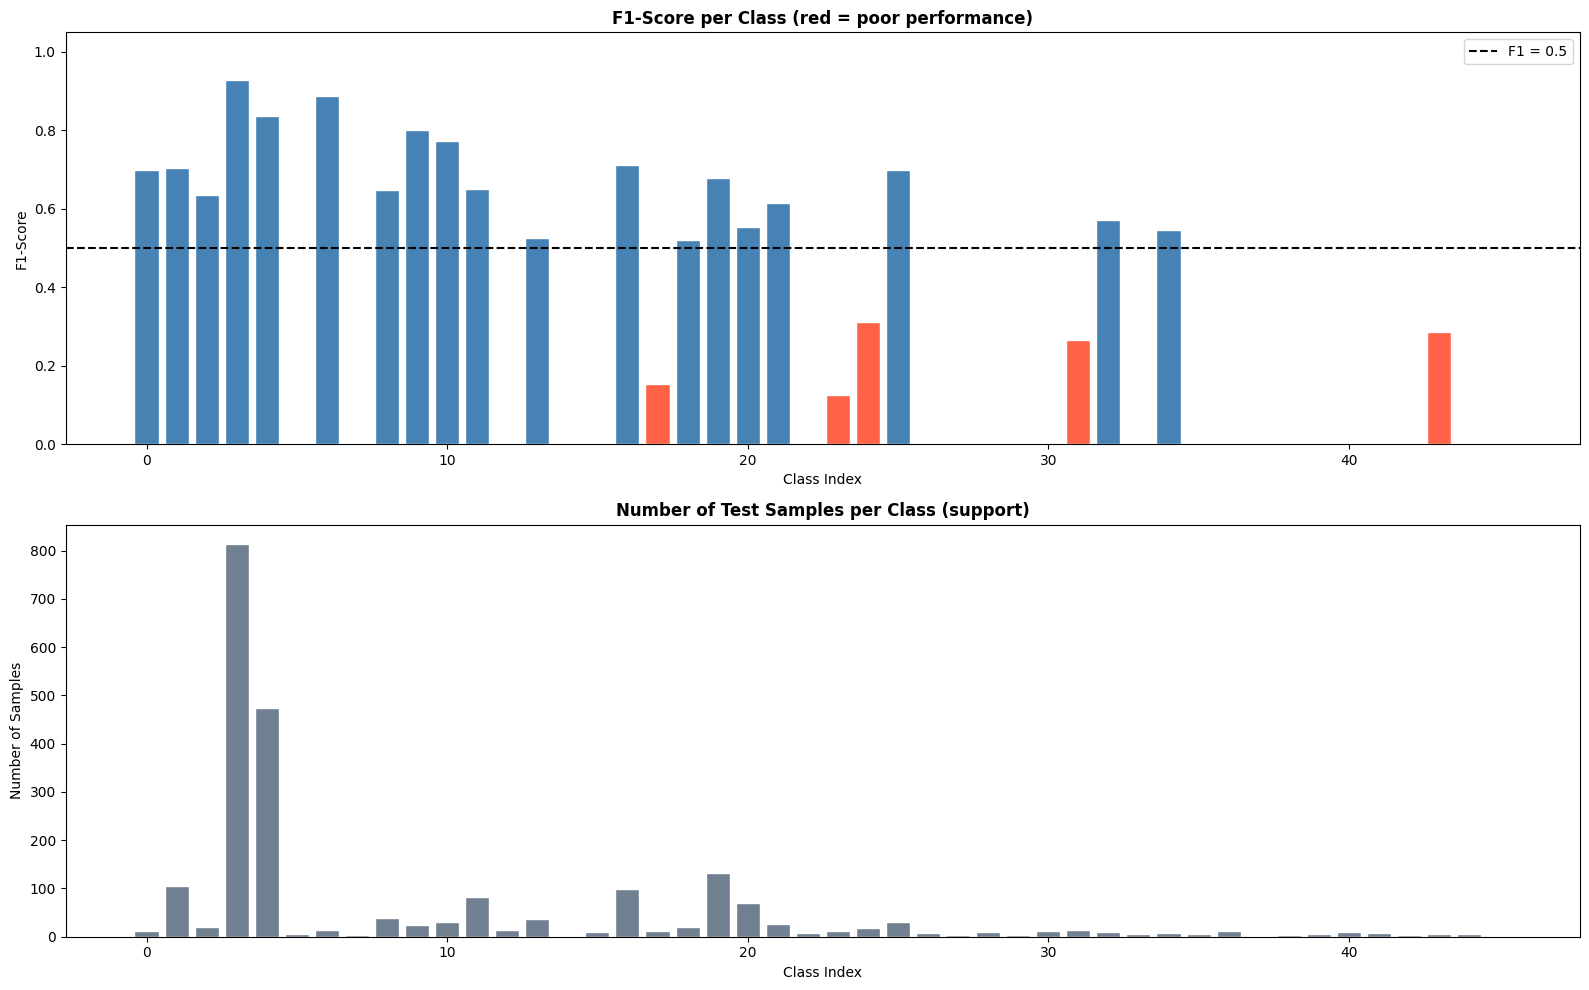

In [ ]:
# ── Which classes does the model handle well vs poorly? ───────────
report_dict = classification_report(y_true, y_pred, output_dict=True)

classes_present = sorted([k for k in report_dict.keys()
                          if k.isdigit()], key=int)

f1_scores   = [report_dict[c]['f1-score']  for c in classes_present]
class_ids   = [int(c) for c in classes_present]
class_sizes = [np.sum(y_true == int(c)) for c in classes_present]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# F1-score per class
colors = ['tomato' if f < 0.5 else 'steelblue' for f in f1_scores]
axes[0].bar(class_ids, f1_scores, color=colors, edgecolor='white')
axes[0].axhline(0.5, color='black', linestyle='--', label='F1 = 0.5')
axes[0].set_title('F1-Score per Class (red = poor performance)', fontweight='bold')
axes[0].set_xlabel('Class Index')
axes[0].set_ylabel('F1-Score')
axes[0].legend()
axes[0].set_ylim(0, 1.05)

# Class size (support)
axes[1].bar(class_ids, class_sizes, color='slategray', edgecolor='white')
axes[1].set_title('Number of Test Samples per Class (support)', fontweight='bold')
axes[1].set_xlabel('Class Index')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.savefig('exp8_per_class_performance.png', dpi=150)
plt.show()

# OBSERVATION: Classes with very few samples tend to have low F1.
# This is the real-world challenge of class imbalance.


### Part J: Using sparse_categorical_crossentropy (Alternative Approach)

In [ ]:
# ── Alternative: Use integer labels directly (no to_categorical) ──
# This is simpler and avoids the one-hot encoding step

def build_model_sparse(units=64, dropout_rate=0.4):
    model = keras.Sequential([
        layers.Dense(units, activation='relu', input_shape=(NUM_WORDS,)),
        layers.Dropout(dropout_rate),
        layers.Dense(units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',  # ★ Works with integer labels
        metrics=['accuracy']
    )
    return model

# Labels stay as integers (NOT one-hot encoded)
y_train_int = y_train[VAL_SIZE:]     # Still integer array
y_val_int   = y_train[:VAL_SIZE]

model_sparse = build_model_sparse()
history_sparse = model_sparse.fit(
    x_train_final, y_train_int,
    epochs=20, batch_size=512,
    validation_data=(x_val, y_val_int),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

_, acc_sparse = model_sparse.evaluate(x_test_vec, y_test, verbose=0)
print(f'\nSparse model test accuracy: {acc_sparse*100:.2f}%')
print('(Should match the one-hot model — same computation, different label format)')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.2523 - loss: 3.4085 - val_accuracy: 0.4910 - val_loss: 2.6908
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4607 - loss: 2.4066 - val_accuracy: 0.5880 - val_loss: 1.7862
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5663 - loss: 1.7978 - val_accuracy: 0.6400 - val_loss: 1.5024
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6384 - loss: 1.5169 - val_accuracy: 0.6900 - val_loss: 1.3408
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6854 - loss: 1.3579 - val_accuracy: 0.7110 - val_loss: 1.2464
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7106 - loss: 1.2163 - val_accuracy: 0.7270 - val_loss: 1.1801
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.7352 - loss: 1.0981 - val_accuracy: 0.7400 - val_loss: 1.1235
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.7575 - loss: 1.0214 - val_accuracy: 0.7580 - v